
File: tumor.root
Entries: 100000

File: phantom.root
Entries: 100000


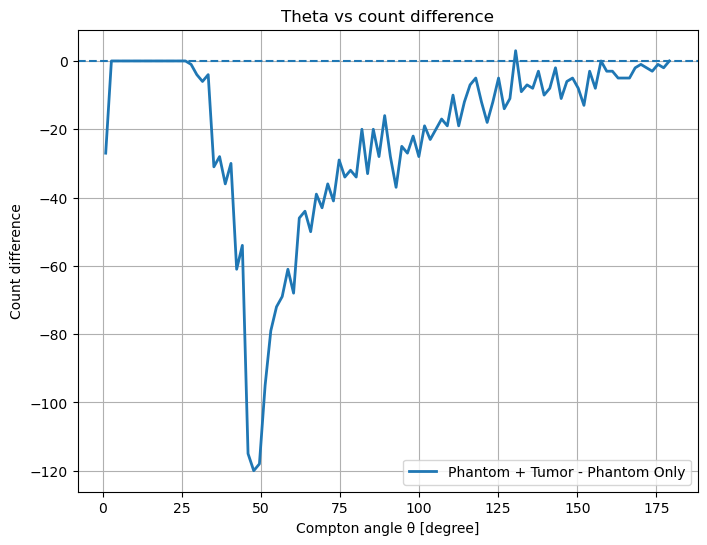

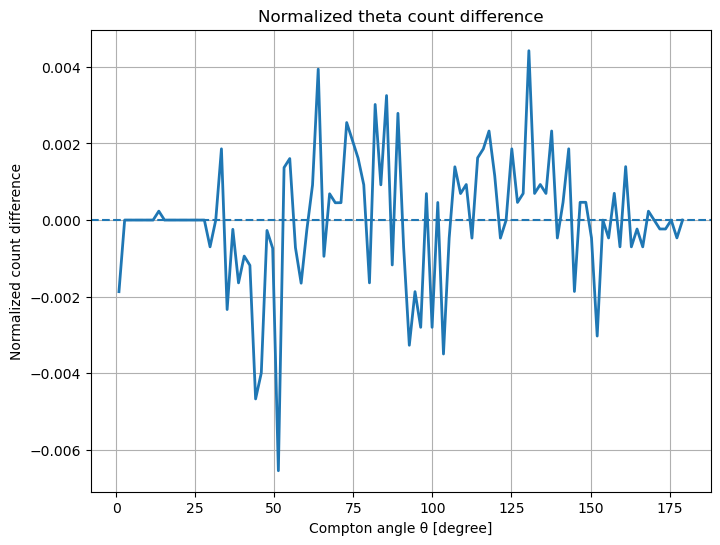

Tumor points: 2147
Phantom points: 4291


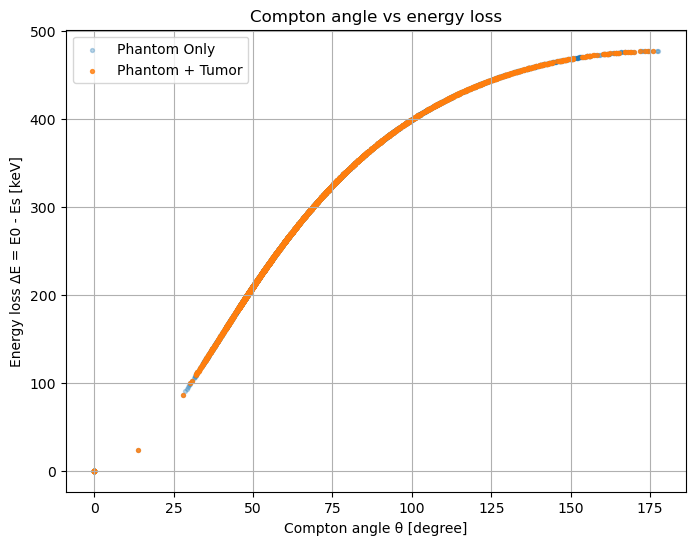

In [2]:
import ROOT
import math
import numpy as np
import matplotlib.pyplot as plt

# =========================
# USER SETTINGS
# =========================
tumor_file = "tumor.root"
phantom_file = "phantom.root"
tree_name = "t"

detector_vlms = [4, 5, 6]

E0 = 662.0   # keV
me = 511.0   # keV

# =========================
# FUNCTION: GET THETA AND ENERGY LOSS
# =========================
def get_theta_energy_loss(root_file):

    f = ROOT.TFile.Open(root_file)
    if not f or f.IsZombie():
        raise RuntimeError(f"Could not open ROOT file: {root_file}")

    t = f.Get(tree_name)
    if not t:
        raise RuntimeError(f"Could not find tree {tree_name} in {root_file}")

    theta_list = []
    eloss_list = []

    print("\nFile:", root_file)
    print("Entries:", t.GetEntries())

    for entry in t:

        n = min(len(entry.pdg), len(entry.vlm), len(entry.et))

        for i in range(n):

            # only detected gammas
            if int(entry.pdg[i]) != 22:
                continue

            # only detector volumes
            if int(entry.vlm[i]) not in detector_vlms:
                continue

            Es = float(entry.et[i])   # scattered gamma energy [keV]

            if Es <= 0 or Es >= E0:
                continue

            # Compton angle from scattered gamma energy
            cos_theta = 1.0 - me * (1.0 / Es - 1.0 / E0)

            if cos_theta < -1.0 or cos_theta > 1.0:
                continue

            theta = math.acos(cos_theta)       # radians
            theta_deg = math.degrees(theta)    # degrees

            energy_loss = E0 - Es              # keV

            theta_list.append(theta_deg)
            eloss_list.append(energy_loss)

    f.Close()

    return np.array(theta_list), np.array(eloss_list)


# =========================
# GET DATA
# =========================
theta_tumor, eloss_tumor = get_theta_energy_loss(tumor_file)
theta_phantom, eloss_phantom = get_theta_energy_loss(phantom_file)
# =========================
# PLOT: THETA vs COUNT DIFFERENCE
# Phantom+Tumor - PhantomOnly
# =========================

bins = np.linspace(0, 180, 101)   # 100 bins from 0 to 180 degrees

# count events in each theta bin
counts_tumor, edges = np.histogram(theta_tumor, bins=bins)
counts_phantom, _ = np.histogram(theta_phantom, bins=bins)

# bin centers for plotting
theta_centers = 0.5 * (edges[:-1] + edges[1:])

# difference
counts_diff = counts_tumor - counts_phantom

plt.figure(figsize=(8, 6))

plt.plot(
    theta_centers,
    counts_diff,
    linewidth=2,
    label="Phantom + Tumor - Phantom Only"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Compton angle θ [degree]")
plt.ylabel("Count difference")
plt.title("Theta vs count difference")
plt.legend()
plt.grid(True)
plt.show()

counts_tumor_norm = counts_tumor / (counts_tumor.sum() + 1e-9)
counts_phantom_norm = counts_phantom / (counts_phantom.sum() + 1e-9)

counts_diff_norm = counts_tumor_norm - counts_phantom_norm

plt.figure(figsize=(8, 6))
plt.plot(theta_centers, counts_diff_norm, linewidth=2)
plt.axhline(0, linestyle="--")

plt.xlabel("Compton angle θ [degree]")
plt.ylabel("Normalized count difference")
plt.title("Normalized theta count difference")
plt.grid(True)
plt.show()

print("Tumor points:", len(theta_tumor))
print("Phantom points:", len(theta_phantom))


# =========================
# PLOT: THETA vs ENERGY LOSS
# =========================
plt.figure(figsize=(8, 6))
plt.scatter(theta_phantom, eloss_phantom,
            s=8, alpha=0.3, label="Phantom Only")

plt.scatter(theta_tumor, eloss_tumor,
            s=8, alpha=0.8, label="Phantom + Tumor")

plt.xlabel("Compton angle θ [degree]")
plt.ylabel("Energy loss ΔE = E0 - Es [keV]")
plt.title("Compton angle vs energy loss")
plt.legend()
plt.grid(True)
plt.show()